In [1]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

inspection_id = "09WMV85VAMM" #fhr4
angle_profiles = ["0"]
num_tracks = 22


In [2]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"./data-files/insp_{inspection_id}_dent_detection_ae_v3_16"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-test-prefect", f"track_runs/{inspection_id}/dent_detection_ae/", results_dir)

In [3]:
results_dir = f"./data-files/test"
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))[0:1]

In [ ]:
data_files

In [ ]:
pd.read_csv(data_files[0])

In [4]:
## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_csv(path)
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

Threshold 0.4: 7/669 passed (7/669 positives, 1.0%)
Threshold 0.5: 7/669 passed (7/669 positives, 1.0%)
Threshold 0.6: 6/669 passed (6/669 positives, 0.9%)
Threshold 0.7: 6/669 passed (6/669 positives, 0.9%)
Threshold 0.8: 5/669 passed (5/669 positives, 0.7%)
Threshold 0.9: 5/669 passed (5/669 positives, 0.7%)
Threshold 1.0: 3/669 passed (3/669 positives, 0.4%)
Threshold 1.0: 3/669 passed (3/669 positives, 0.4%)


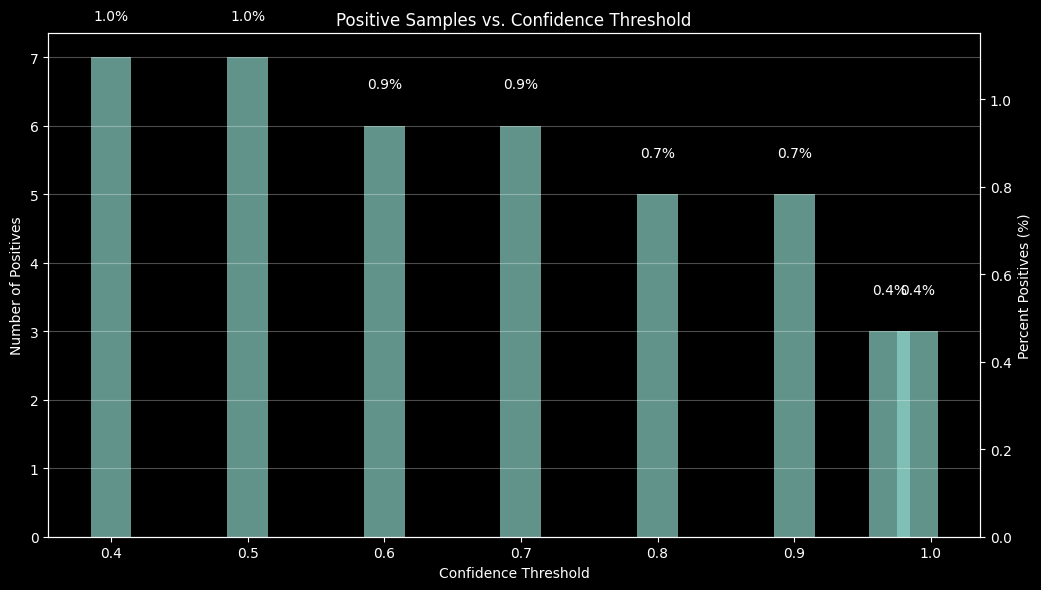

In [5]:
# Assuming all_dfs is your dataframe with columns: start, end, and prob
import ast

# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

# Process each threshold
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97, 0.99]
results = []
all_dfs = create_df()

for threshold in thresholds:
    # Lists to store entries that pass the threshold
    filtered_entries = []
    total_samples = len(all_dfs)
    num_positives = 0
    
    # Process each row
    for i, row in all_dfs.iterrows():
        # Parse the probability values if needed
        probs = parse_prob(row['prob'])
        
        # Check if any probability exceeds the threshold
        if any(p >= threshold for p in probs):
            # Add this entry to our filtered list
            filtered_entries.append({
                'start': row['start'],
                'end': row['end'],
                'prob': probs,
                'max_prob': max(probs)
            })
            num_positives += 1
    
    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'filtered_entries': filtered_entries,
        'num_positives': num_positives,
        'total': total_samples,
        'num_positives_percent': (num_positives / total_samples) * 100 if total_samples > 0 else 0
    })
    print(f"Threshold {threshold:.1f}: {len(filtered_entries)}/{total_samples} passed "
          f"({num_positives}/{total_samples} positives, {num_positives/total_samples:.1%})")

# Plotting the results
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
num_positives_counts = [r['num_positives'] for r in results]
num_positives_percent = [r['num_positives_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, num_positives_counts, width=0.03, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, num_positives_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.1f}%', ha='center', va='bottom')


# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Positives')
plt.title('Positive Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Positives (%)')
ax2.plot(thresholds, num_positives_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(num_positives_percent) * 1.1)

plt.show()

In [6]:
# Access filtered entries for threshold 0.9
entries_09 = results[7]['filtered_entries']  # Index 5 corresponds to threshold 0.9
print(f"Found {len(entries_09)} entries above threshold 0.9")

# Optional: Create a new DataFrame with filtered entries
import pandas as pd
filtered_df = pd.DataFrame(entries_09)
display(filtered_df)

Found 3 entries above threshold 0.9


,start,end,prob,max_prob
0,436.75,437.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9948
1,436.90,437.20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9957
2,496.00,496.30,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9963


In [7]:
def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with larger start value.
    
    Args:
        df: DataFrame with 'start' column
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start column in descending order (larger values first)
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Initialize with first row (largest start value)
    kept_indices = [0]
    last_kept_start = df_sorted.loc[0, 'start']
    
    # Process remaining rows
    for i in range(1, len(df_sorted)):
        current_start = df_sorted.loc[i, 'start']
        
        # If far enough from last kept row, keep this one too
        # Note: Since we're going from larger to smaller, the comparison is flipped
        if last_kept_start - current_start >= distance_threshold:
            kept_indices.append(i)
            last_kept_start = current_start
    
    # Return dataframe with only kept rows
    return df_sorted.loc[kept_indices].reset_index(drop=True)

# Example usage
filtered_df_deduped = filter_close_detections(filtered_df)
print(f"Original detections: {len(filtered_df)}")
print(f"After deduplication: {len(filtered_df_deduped)}")

Original detections: 3
After deduplication: 2


In [8]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

run_number = 6
root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)

session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img


Added /home/zmirikha/GitHub/rnd_q2 to Python path
PySettings.cpp(46): ilipy: Build 0.17.5.11628 cbc18e3397 release-ili-0.17 'Tue Sep 16 22:43:55 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: za

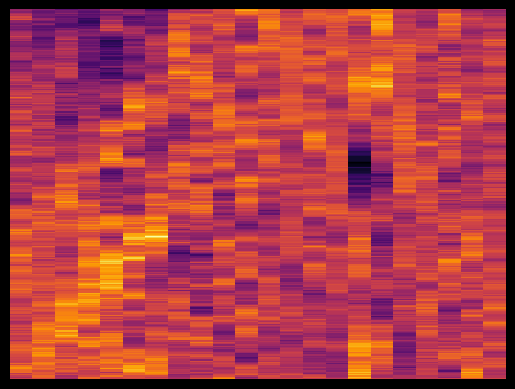

496.14999999998554 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9963, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0]


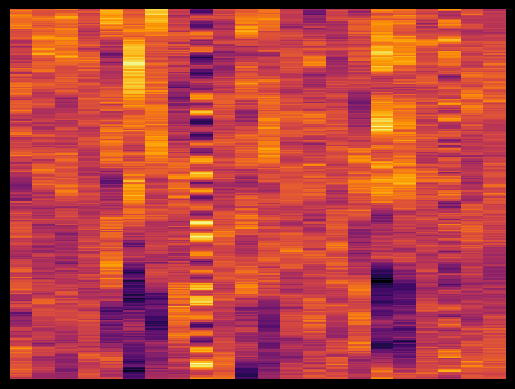

437.0499999999944 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.9957, 0.9324, 0.0, 0.0, 0.0, 0.0]


DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [ ]:
for i, row in filtered_df_deduped.iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

    print(vd, row['prob'])

In [ ]:
img_std = gen_image(167100.4999999961, session, dist_corr, length=0.3, show_im=True, normalize="std")
